# Lab 04 - Generating CDFs

Lukas Vrouwenvelder

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, beta, uniform

In [45]:
def plot_ecdf(samples, theoretical_cdf=None, x_range=None, label="simulated", title=""):
    '''Reusable function to plot the ecdf in each distribution'''
    x = np.sort(samples)
    y = np.arange(1, len(x) + 1) / len(x)
    plt.step(x, y, where="post", label=label)
    if theoretical_cdf is not None:
        grid = x_range if x_range is not None else np.linspace(x.min(), x.max(), 500)
        plt.plot(grid, theoretical_cdf(grid), "r--", label="theoretical CDF")
    plt.xlabel("value"); plt.ylabel("F(x)"); plt.title(title); plt.legend()
    plt.show()

---

### Q1

In [46]:
def make_grid(k):
    return np.arange(1, k + 1) / k 
make_grid(10)

array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [47]:
def sample_picker(n, k):
    grid = make_grid(k)
    idx = np.random.randint(0, k, size=n)
    return grid[idx]
sample_picker(5,10000)

array([0.8962, 0.9571, 0.5017, 0.1067, 0.7601])

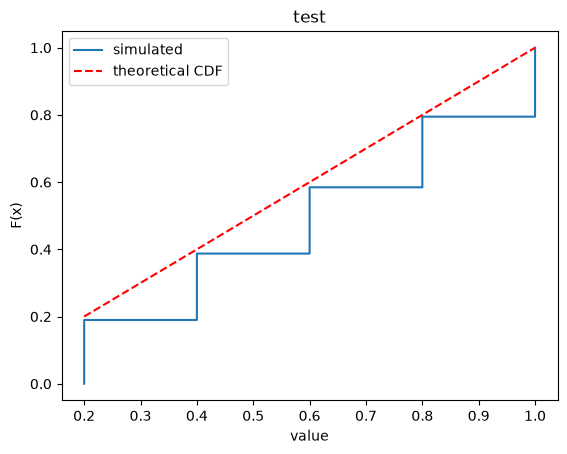

In [61]:
k_small = 5
n_reps = 5000
small_grid = make_grid(k_small)
samples_small = sample_picker(n_reps,k_small)
plot_ecdf(samples_small, theoretical_cdf=lambda x: uniform.cdf(x, loc=0, scale=1), x_range=None, label="simulated", title="test")

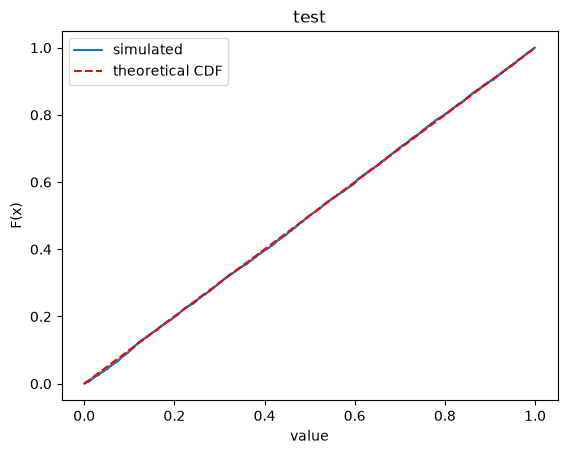

In [51]:
k_small = 50000
n_reps = 5000
small_grid = make_grid(k_small)
samples_large = sample_picker(n_reps,k_small)

plot_ecdf(samples_large,
          theoretical_cdf=lambda x: uniform.cdf(x, loc=0, scale=1),
          x_range=np.linspace(0, 1, 500),
          label="simulated", title="test")

#### Response 

This is the uniform distribution; all values demonstrate equal probability. 

When `K` is a small number like 5, the distribution clearly shows the discrete characteristics, jumping from one value to the next with even distribution, but limited values, to give the CDF a stair-like appearance. 

When `K` is adjusted to a larger number (like 5,000 or 50,000), the distribution becomes much smoother, as the jump between discrete values (still the same size: 1) becomes smaller relative to the highest value (50,000). This gives the plot a linear appearance, as it converges on a smooth distribution.

---

### Q2

In [ ]:
def sample_means(n, b):
    """Draw b samples of size n from Uniform[-sqrt(3), sqrt(3)],
    return sqrt(n) * sample mean for each of the b samples."""
    draws = np.random.uniform(-np.sqrt(3), np.sqrt(3), size=(b, n))
    means = draws.mean(axis=1)      # one mean per row -> array of length b
    return np.sqrt(n) * means

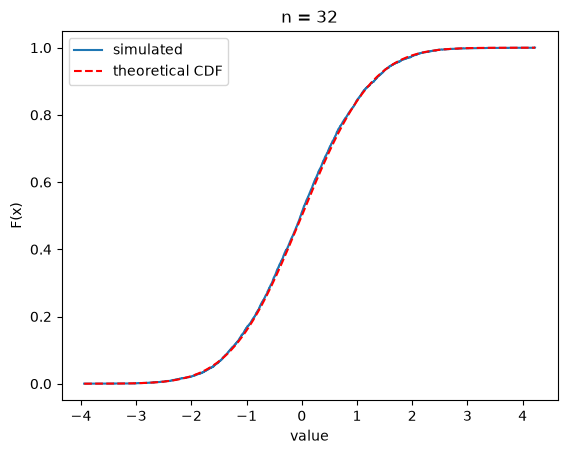

In [59]:
n = 32
b = 5000
standardized_means = sample_means(n, b)

plot_ecdf(
    standardized_means,
    theoretical_cdf=lambda x: norm.cdf(x, loc=0, scale=1),
    # x_range=np.linspace(-4, 4, 500),
    x_range = None,
    title=f"n = {n}",
)

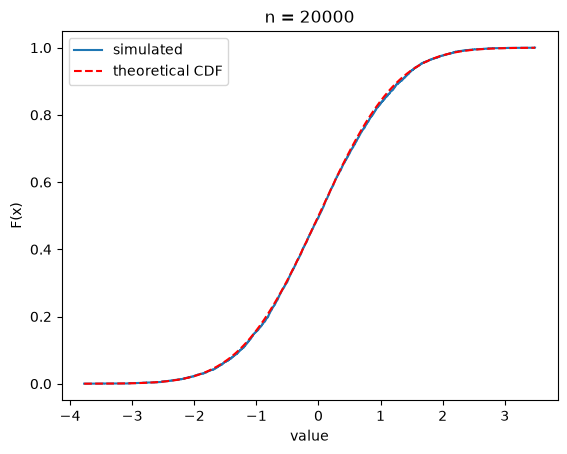

In [54]:
n = 20000
b = 5000
standardized_means = sample_means(n, b)

plot_ecdf(
    standardized_means,
    theoretical_cdf=lambda x: norm.cdf(x, loc=0, scale=1),
    # x_range=np.linspace(-4, 4, 500),
    x_range = None,
    title=f"n = {n}",
)

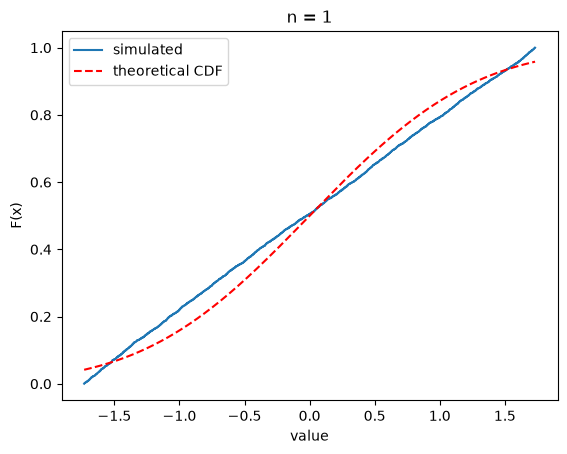

In [60]:
n = 1
b = 5000
standardized_means = sample_means(n, b)

plot_ecdf(
    standardized_means,
    theoretical_cdf=lambda x: norm.cdf(x, loc=0, scale=1),
    # x_range=np.linspace(-4, 4, 500),
    x_range = None,
    title=f"n = {n}",
)

#### Response

In this function, as `n` increases, the plot's shape of a normal cumulative distribution function remains very similar, with the highest number of data points in the center (steepest slope) at a value of 0, and a lessening slope that approaches 0 at either extreme (-3 and +3) as the distribution of data points becomes more sparce. 

This is a mechanic of the Central Limit Theorem, which asserts that 'well-behaved' distributions will converge to normal more quickly than 'ill-behaved' distributions. The `Uniform[-√3, √3]` distribution is 'well-behaved,' which is why it converges on it's target distribution at both 32 and 20,000 for values of `n`. 

Still, the actual distribution fails to match it's target dist. at an extreme value like `n=1`; as pictured, the plot is simply a line. 

---

### Q3

In [ ]:
# n = 40
# p = 1/2

def flipper(flips, prob):
    coinFlip =[]
    for i in range(0,flips):
        rand = np.random.randint(0, 10000)
        if rand >= prob*10000:
            coinFlip.append('T')
        else:
            coinFlip.append('H')
    return coinFlip

# coinflips =  flipper(n,p)

In [ ]:
def qThreeFunction(n,p,reps):
    heads = 0
    d_point = []
    for i in range(0, reps):
        coinflips = flipper(n,p)
        heads = (len([h for h in coinflips if h == "H"]) - (p*n)) / (np.sqrt(n * p * (1-p)))
        d_point.append(heads)
    return d_point

qThree_data = qThreeFunction(40,.5,5000)

qThree_data_high_n = qThreeFunction(500,.5,5000)


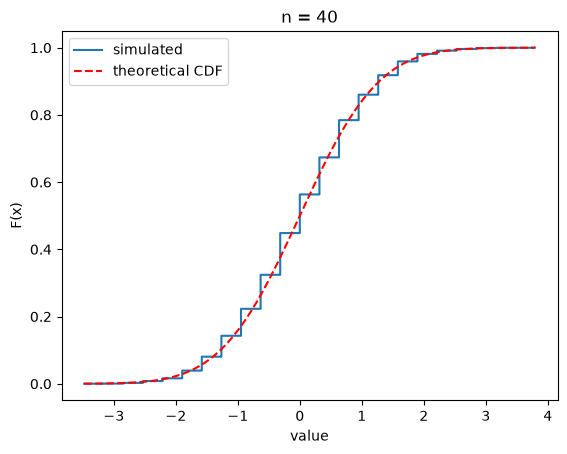

In [ ]:
plot_ecdf(
    qThree_data,
    theoretical_cdf=lambda x: norm.cdf(x, loc=0, scale=1),
    # x_range=np.linspace(-4, 4, 500),
    x_range = None,
    title=f"n = {40}",
)

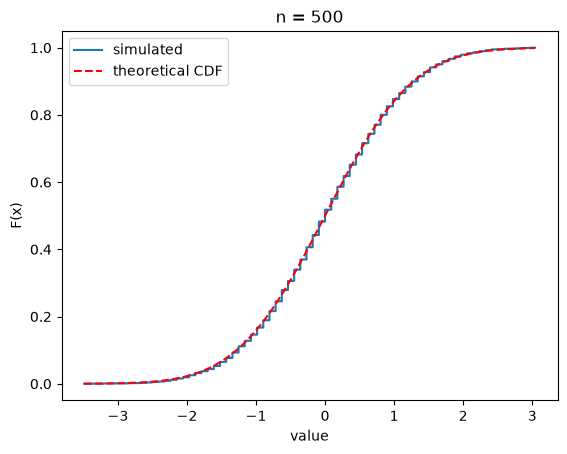

In [ ]:
plot_ecdf(
    qThree_data_high_n,
    theoretical_cdf=lambda x: norm.cdf(x, loc=0, scale=1),
    # x_range=np.linspace(-4, 4, 500),
    x_range = None,
    title=f"n = {500}",
)

In [ ]:
qThree_data_high_p = qThreeFunction(500,.985,5000)


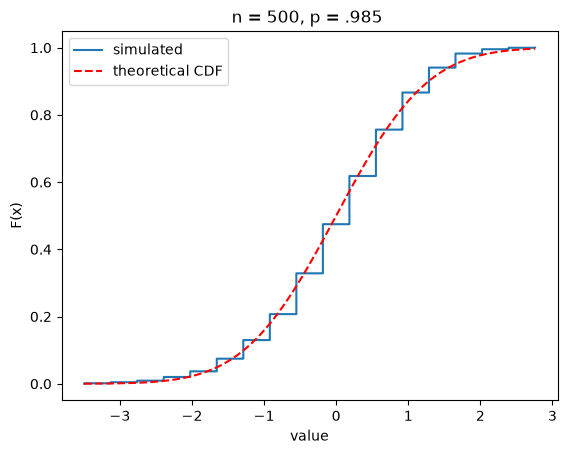

In [ ]:
plot_ecdf(
    qThree_data_high_p,
    theoretical_cdf=lambda x: norm.cdf(x, loc=0, scale=1),
    # x_range=np.linspace(-4, 4, 500),
    x_range = None,
    title=f"n = 500, p = .985 ",
)

This plot smooths and approaches the standard normal distribution as `n` (the number of times we flip the coin) increases. This is demonstrated between the ploys where n=40 and n=500. They both resemble the normal distribution, but when n=500, the plot is less jagged and sits closer to the theoretical distribution at more points. 

As `p` increases, the function loses it's smoothness, but remains the normal distribution no matter what value `p` takes. The variance of the data shrinks as `p` shrinks or grows on either side of .5 (`n·p·(1−p)`). As a result, the number of distinct values that each random draw can take drops, leading to the 'sparce-looking' plot we see at extreme `p` values. 

---

### Q5

In [ ]:
K = 20
b = 5_000

def order_statistics(K, b):
    """Draw b samples of K Uniform(0,1) values each, sorted within each sample."""
    draws = np.random.uniform(0, 1, size=(b, K))
    draws.sort(axis=1)
    return draws

samples = order_statistics(K, b)

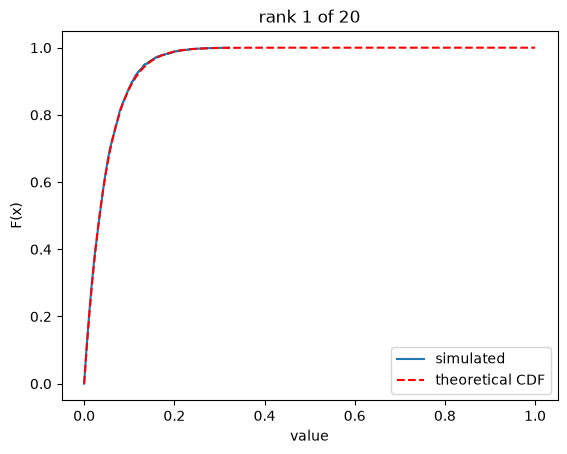

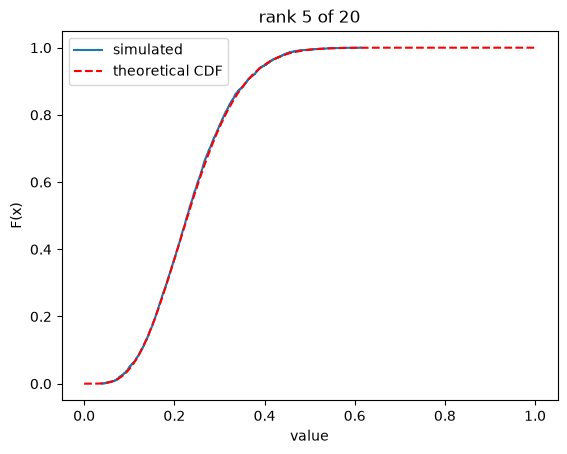

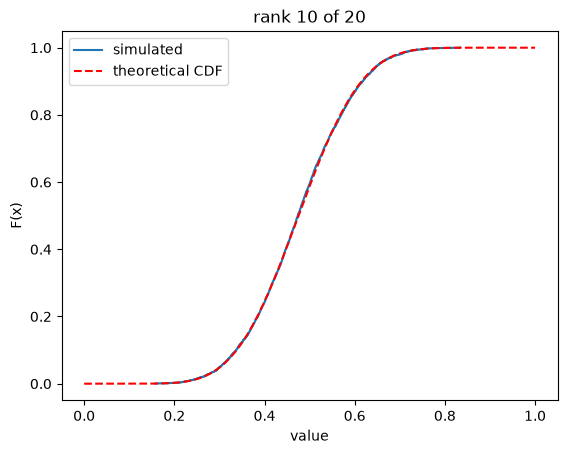

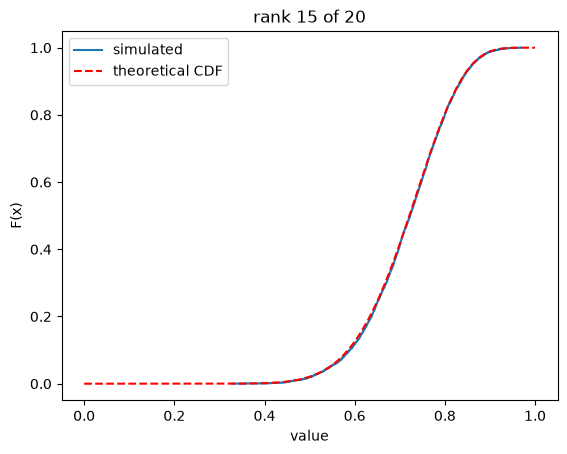

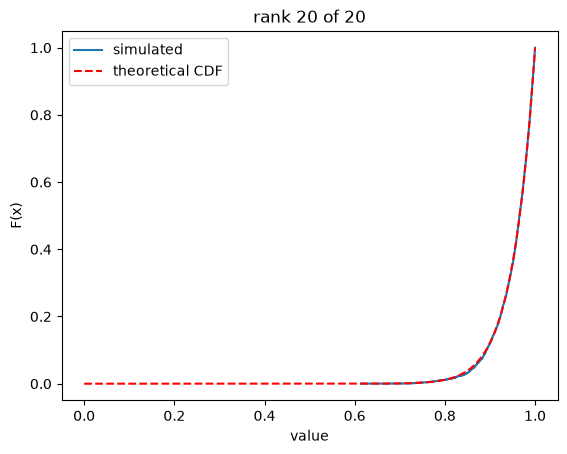

In [ ]:
for rank in [1, 5, 10, 15, 20]:
    rank_values = samples[:, rank - 1]
    plot_ecdf(rank_values,
              theoretical_cdf=lambda x, r=rank: beta.cdf(x, r, K - r + 1),
              x_range=np.linspace(0, 1, 500), title=f"rank {rank} of {K}")

#### Response

- While these these plots may resemble log function, normal distribution, or exponential function, they're all the beta distribution, as can be seen when comparing the theoretical beta curve against our `rank_values` data. They adopt different shape parameters as `r` changes, but they are still well-modeled by the same beta function. 

- As r increases from 1 to 20, the center of the distribution slides steadily to the right. Because the mean of Beta(r, K-r+1) is r/(K+1), rank 1's distribution centers near 0.05, rank 10's centers near 0.48, and rank 20's centers near 0.95. Each successive rank sits further to the right than the last.
